<a href="https://colab.research.google.com/github/rfortuna98/QNC-Fall-2025/blob/main/ex_phe_coc_fem_ch1%2B2_RE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Data Preview ===
   animal treatment  LeverPress  BodyMass
0       3    0ug/kg         106       312
1       3    3ug/kg         216       315
2       3   10ug/kg         187       305
3       5    0ug/kg         160       337
4       5    3ug/kg          72       341


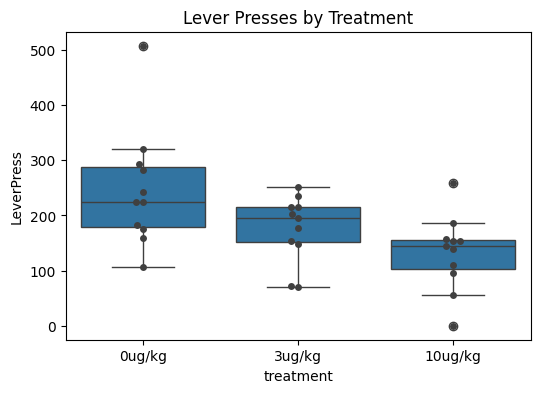

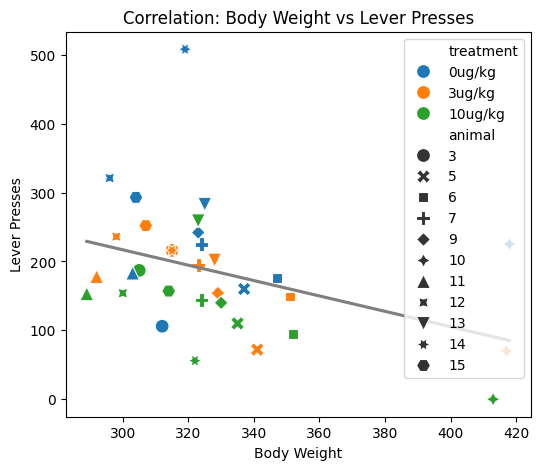


Pearson correlation: r = -0.39, p = 0.024


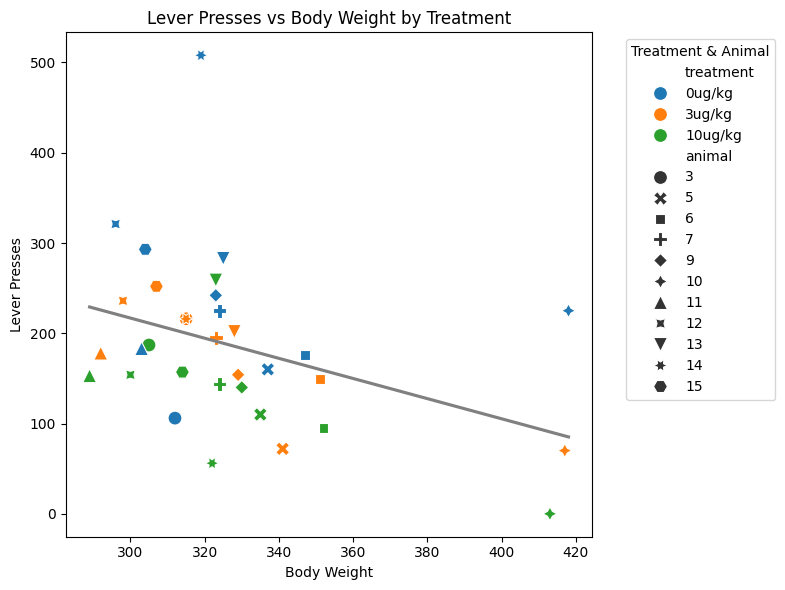

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# === Load data from CSV ===
# Replace 'data.csv' with your actual filename
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Ex-phe-coc-fem RE ALxBW.csv')

print("\n=== Data Preview ===")
print(df.head())

# === Box + Swarm Plot: Lever Presses by Treatment ===
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='treatment', y='LeverPress')
sns.swarmplot(data=df, x='treatment', y='LeverPress', color=".25")
plt.title('Lever Presses by Treatment')
plt.show()

# === Scatter + Regression: Body Weight vs Lever Presses ===
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    hue='treatment',
    style='animal',
    s=100
)
sns.regplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    scatter=False,
    ci=None,
    color='gray'
)
plt.title('Correlation: Body Weight vs Lever Presses')
plt.xlabel('Body Weight')
plt.ylabel('Lever Presses')
plt.show()

# === Pearson Correlation ===
corr, p_value = pearsonr(df['BodyMass'], df['LeverPress'])
print(f"\nPearson correlation: r = {corr:.2f}, p = {p_value:.3f}")

# === Final Scatter (same as before, with legend styling) ===
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    hue='treatment',
    style='animal',
    s=100
)
sns.regplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    scatter=False,
    ci=None,
    color='gray'
)
plt.title('Lever Presses vs Body Weight by Treatment')
plt.xlabel('Body Weight')
plt.ylabel('Lever Presses')
plt.legend(title='Treatment & Animal', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


=== Data Preview ===
   animal treatment  LeverPress  BodyMass
0       3    0ug/kg         106       312
1       3    3ug/kg         216       315
2       3   10ug/kg         187       305
3       5    0ug/kg         160       337
4       5    3ug/kg          72       341


<Figure size 800x600 with 0 Axes>

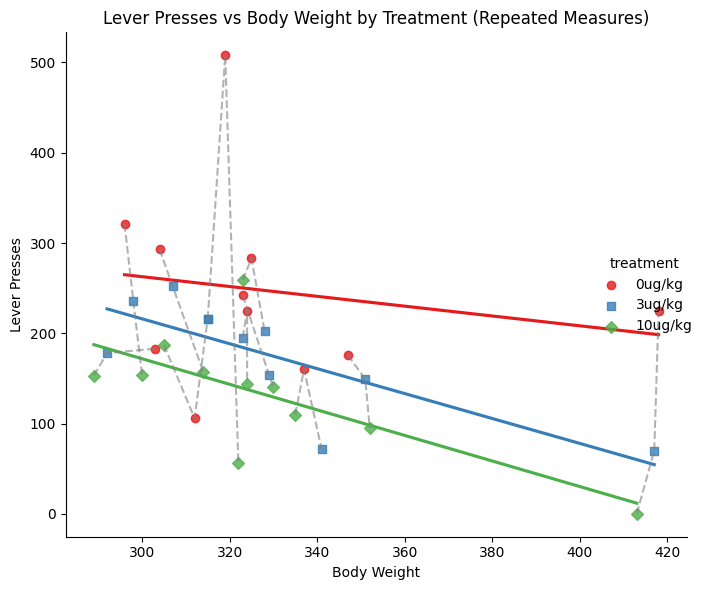

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load data from CSV ===
# Replace 'data.csv' with your actual file name or path
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Ex-phe-coc-fem RE ALxBW.csv')

print("\n=== Data Preview ===")
print(df.head())

# === Repeated-Measures Scatter Plot ===
plt.figure(figsize=(8,6))

# Scatter + regression lines per treatment
sns.lmplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    hue='treatment',
    markers=['o', 's', 'D'],   # different marker shapes per treatment
    palette='Set1',
    ci=None,
    height=6,
    aspect=1
)

# Overlay repeated-measure lines for each animal
for animal in df['animal'].unique():
    animal_data = df[df['animal'] == animal].sort_values('BodyMass')
    plt.plot(
        animal_data['BodyMass'],
        animal_data['LeverPress'],
        color='gray',
        linestyle='--',
        alpha=0.6
    )

plt.title('Lever Presses vs Body Weight by Treatment (Repeated Measures)')
plt.xlabel('Body Weight')
plt.ylabel('Lever Presses')
plt.tight_layout()
plt.show()


=== Data Preview ===
   animal treatment  LeverPress  BodyMass
0       3    0ug/kg         106       312
1       3    3ug/kg         216       315
2       3   10ug/kg         187       305
3       5    0ug/kg         160       337
4       5    3ug/kg          72       341


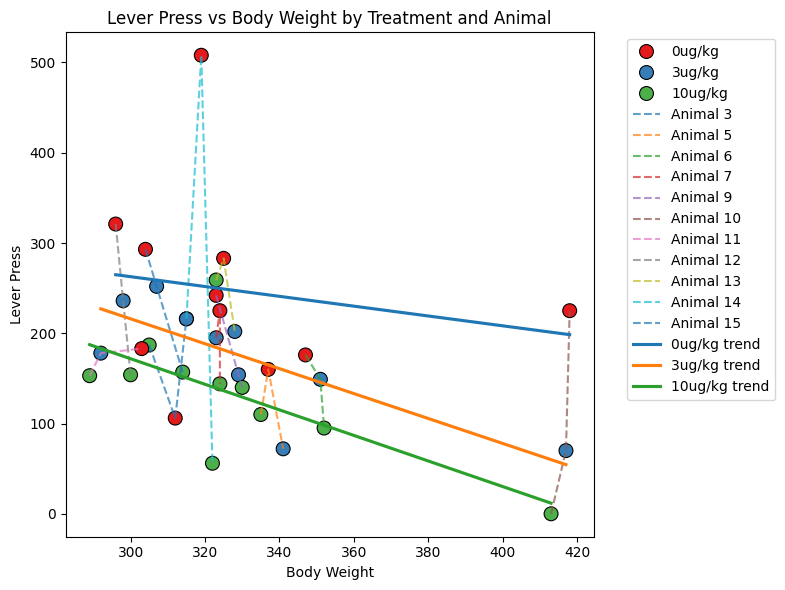

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load CSV data ===
# Replace 'data.csv' with your actual filename
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Ex-phe-coc-fem RE ALxBW.csv')

print("\n=== Data Preview ===")
print(df.head())

plt.figure(figsize=(8,6))

# === Scatter points: colored by Treatment ===
sns.scatterplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    hue='treatment',
    palette='Set1',
    s=100,
    edgecolor='black',
    legend='full'
)

# === Connect repeated measures per Animal (colored by Animal) ===
animals = df['animal'].unique()
palette_animals = sns.color_palette("tab10", len(animals))

for i, animal in enumerate(animals):
    animal_data = df[df['animal'] == animal].sort_values('BodyMass')
    plt.plot(
        animal_data['BodyMass'],
        animal_data['LeverPress'],
        color=palette_animals[i],
        linestyle='--',
        alpha=0.7,
        label=f"Animal {animal}"
    )

# === Add separate regression lines per Treatment ===
for treatment in df['treatment'].unique():
    treatment_data = df[df['treatment'] == treatment]
    sns.regplot(
        data=treatment_data,
        x='BodyMass',
        y='LeverPress',
        scatter=False,
        ci=None,
        label=f"{treatment} trend",
        line_kws={'linestyle':'-'}
    )

plt.xlabel('Body Weight')
plt.ylabel('Lever Press')
plt.title('Lever Press vs Body Weight by Treatment and Animal')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np

# === Load data from CSV ===
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Ex-phe-coc-fem RE ALxBW.csv')

# Check which lever column exists
if 'LeverPress' in df.columns:
    lever_col = 'LeverPress'
elif 'Lever_Presses' in df.columns:
    lever_col = 'Lever_Presses'
else:
    raise KeyError("CSV must contain a 'LeverPress' or 'Lever_Presses' column.")

print("\n=== Data Preview ===")
print(df.head())

# === Create weight bins ===
bins = [280, 300, 320, 340, 360, 400]
labels = ['280–300', '300–320', '320–340', '340–360', '360–400']
df['Weight_Bin'] = pd.cut(df['BodyMass'], bins=bins, labels=labels)

# === Compute mean, variance, std, count per bin ===
variance_df = (
    df.groupby('Weight_Bin', observed=False)[lever_col]
      .agg(['mean', 'var', 'std', 'count'])
      .reset_index()
)

print("\n=== Lever Press Statistics by Body Weight Bin ===")
print(variance_df.round(2))


=== Data Preview ===
   animal treatment  LeverPress  BodyMass
0       3    0ug/kg         106       312
1       3    3ug/kg         216       315
2       3   10ug/kg         187       305
3       5    0ug/kg         160       337
4       5    3ug/kg          72       341

=== Lever Press Statistics by Body Weight Bin ===
  Weight_Bin    mean       var     std  count
0    280–300  208.40   5098.30   71.40      5
1    300–320  235.33  13329.50  115.45      9
2    320–340  180.83   4333.42   65.83     12
3    340–360  123.00   2290.00   47.85      4
4    360–400     NaN       NaN     NaN      0


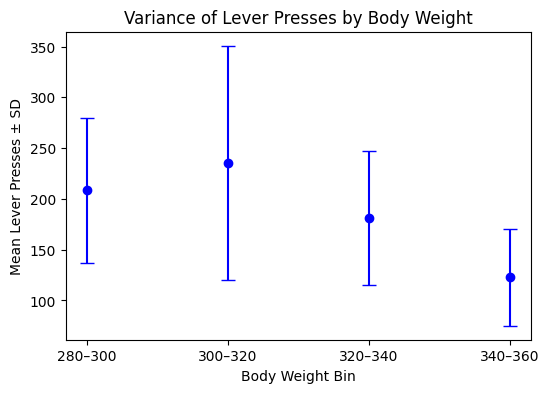

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.errorbar(
    variance_df['Weight_Bin'],
    variance_df['mean'],
    yerr=variance_df['std'],
    fmt='o',
    capsize=5,
    color='blue'
)
plt.xlabel('Body Weight Bin')
plt.ylabel('Mean Lever Presses ± SD')
plt.title('Variance of Lever Presses by Body Weight')
plt.show()

In [13]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation (linear relationship)
r, p = pearsonr(df['BodyMass'], df['LeverPress'])
print(f"Pearson correlation: r = {r:.2f}, p = {p:.3f}")

# Spearman correlation (monotonic relationship)
rho, p_s = spearmanr(df['BodyMass'], df['LeverPress'])
print(f"Spearman correlation: rho = {rho:.2f}, p = {p_s:.3f}")

Pearson correlation: r = -0.39, p = 0.024
Spearman correlation: rho = -0.41, p = 0.019


In [15]:
import statsmodels.api as sm

# Predictor (body weight)
X = df['BodyMass']
X = sm.add_constant(X)  # adds intercept
y = df['LeverPress']

# Fit linear regression
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             LeverPress   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     5.670
Date:                Wed, 05 Nov 2025   Prob (F-statistic):             0.0236
Time:                        14:26:50   Log-Likelihood:                -192.82
No. Observations:                  33   AIC:                             389.6
Df Residuals:                      31   BIC:                             392.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        551.6673    154.558      3.569      0.0

In [17]:
import statsmodels.formula.api as smf

# Mixed-effects: Animal as random effect
model = smf.mixedlm("LeverPress ~ BodyMass", df, groups=df["animal"])
result = model.fit()
print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: LeverPress
No. Observations: 33      Method:             REML      
No. Groups:       11      Scale:              7334.0336 
Min. group size:  3       Log-Likelihood:     -189.1183 
Max. group size:  3       Converged:          No        
Mean group size:  3.0                                   
--------------------------------------------------------
            Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept  552.299  157.866  3.499 0.000 242.887 861.710
BodyMass    -1.118    0.479 -2.335 0.020  -2.056  -0.180
Group Var  119.745   25.565                             



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.889175
  warnings.warn(msg, ConvergenceWarning)


In [19]:
import pandas as pd
import statsmodels.formula.api as smf

# === Load CSV data ===
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Ex-phe-coc-fem RE ALxBW.csv')

print("\n=== Data Preview ===")
print(df.head())

# === Mixed Linear Model ===
# Fixed effects: treatment and Body_Weight
# Random effects: animal (random intercepts)
model = smf.mixedlm("LeverPress ~ treatment + BodyMass", data=df, groups=df["animal"])
result = model.fit(reml=True)  # REML is standard for mixed models

# === Display results ===
print("\n=== Mixed Linear Model Regression Results ===")
print(result.summary())

# === Extract key parts ===
print("\nFixed Effects Coefficients:")
print(result.fe_params.round(3))

print("\nRandom Effects Variance (animal):")
print(result.cov_re.round(3))

print("\nResidual Variance:")
print(result.scale.round(3))


=== Data Preview ===
   animal treatment  LeverPress  BodyMass
0       3    0ug/kg         106       312
1       3    3ug/kg         216       315
2       3   10ug/kg         187       305
3       5    0ug/kg         160       337
4       5    3ug/kg          72       341

=== Mixed Linear Model Regression Results ===
               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     LeverPress
No. Observations:     33          Method:                 REML      
No. Groups:           11          Scale:                  5245.2375 
Min. group size:      3           Log-Likelihood:         -174.4602 
Max. group size:      3           Converged:              Yes       
Mean group size:      3.0                                           
--------------------------------------------------------------------
                      Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
--------------------------------------------------------------------
Inter

| Term                  | Meaning                                                                                                                 | How to Interpret                               |
| --------------------- | ----------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------- |
| **Intercept**         | Expected mean of `Lever_Press` when all predictors = baseline (e.g., Treatment = 0ug, Body_Weight = 0 or mean-centered) | The baseline lever pressing level              |
| **Treatment[T.3ug]**  | Difference in `Lever_Press` between `3ug` and the reference treatment (`0ug`)                                           | Negative = fewer lever presses after treatment |
| **Treatment[T.10ug]** | Same, comparing `10ug` to baseline                                                                                      | Larger negative = stronger suppression         |
| **Body_Weight**       | Slope showing how lever presses change per unit body weight                                                             | Positive = heavier animals press more          |


In [21]:
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import chi2

# === Load your CSV ===
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Ex-phe-coc-fem RE ALxBW.csv')

# Make sure treatment is treated as a categorical variable
df['treatment'] = df['treatment'].astype('category')

print("\n=== Data Preview ===")
print(df.head())

# === Model 1: Without interaction ===
model1 = smf.mixedlm("LeverPress ~ treatment + BodyMass", data=df, groups=df["animal"])
result1 = model1.fit(reml=False)  # use ML for model comparison

# === Model 2: With interaction ===
model2 = smf.mixedlm("LeverPress ~ treatment * BodyMass", data=df, groups=df["animal"])
result2 = model2.fit(reml=False)

# === Print summaries ===
print("\n=== Model 1: No Interaction ===")
print(result1.summary())

print("\n=== Model 2: With Interaction ===")
print(result2.summary())

# === Likelihood Ratio Test ===
# Compare model fits using chi-square test
lr_stat = 2 * (result2.llf - result1.llf)
df_diff = result2.df_modelwc - result1.df_modelwc
p_value = chi2.sf(lr_stat, df_diff)

print("\n=== Model Comparison (Likelihood Ratio Test) ===")
print(f"Model 1 log-likelihood: {result1.llf:.3f}")
print(f"Model 2 log-likelihood: {result2.llf:.3f}")
print(f"Chi²({df_diff:.0f}) = {lr_stat:.3f}, p = {p_value:.3f}")
print(f"Model 1 AIC: {result1.aic:.2f}, Model 2 AIC: {result2.aic:.2f}")

# === Interpretation ===
if p_value < 0.05:
    print("\n✅ The interaction model fits significantly better — body weight affects treatment response.")
else:
    print("\n❌ The interaction model does NOT improve the fit — body weight does not significantly modify treatment effects.")


=== Data Preview ===
   animal treatment  LeverPress  BodyMass
0       3    0ug/kg         106       312
1       3    3ug/kg         216       315
2       3   10ug/kg         187       305
3       5    0ug/kg         160       337
4       5    3ug/kg          72       341


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



=== Model 1: No Interaction ===
               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     LeverPress
No. Observations:     33          Method:                 ML        
No. Groups:           11          Scale:                  4710.6117 
Min. group size:      3           Log-Likelihood:         -186.3749 
Max. group size:      3           Converged:              Yes       
Mean group size:      3.0                                           
--------------------------------------------------------------------
                      Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
--------------------------------------------------------------------
Intercept             613.386  124.500  4.927 0.000  369.371 857.400
treatment[T.10ug/kg] -115.283   29.266 -3.939 0.000 -172.643 -57.924
treatment[T.3ug/kg]   -70.280   29.267 -2.401 0.016 -127.642 -12.918
BodyMass               -1.116    0.374 -2.981 0.003   -1.849  -0.382
Group Var        